<p style="font-size:16px; line-height:1.6;">
<b>Project:</b> Credit Risk Prediction and Default Analysis<br>
<b>Name:</b> Aneel Hassan<br>
<b>Submitted to:</b> Sir Hassan Raza<br>
<b>Subject:</b> Machine Learning<br>
<b>Program:</b> BSBI<br>
<b>Semester:</b> 5th
</p>

<p style="font-size:22px;"><b>Import Libraries</b></p>

In [21]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


<p style="font-size:22px;"><b>Load Dataset</b></p>

In [24]:
# LOAD DATASET
df = pd.read_csv("credit.csv")

<p style="font-size:22px;"><b>Basic EDA & Preprocessing</b></p>

In [30]:
print("First 5 rows:")
print(df.head(5))



First 5 rows:
   observation_id  checking_balance  months_loan_duration credit_history  \
0               0             -43.0                     6       critical   
1               1              75.0                    48         repaid   
2               2               NaN                    12       critical   
3               3             -32.0                    42         repaid   
4               4             -23.0                    24        delayed   

     purpose  amount  savings_balance employment_length  installment_rate  \
0   radio/tv    1169              NaN          13 years                 4   
1   radio/tv    5951             89.0           2 years                 2   
2  education    2096             24.0           5 years                 2   
3  furniture    7882              9.0           5 years                 2   
4  car (new)    4870             43.0           3 years                 3   

  personal_status  ... age installment_plan   housing  existing_cr

In [31]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   observation_id        1000 non-null   int64  
 1   checking_balance      606 non-null    float64
 2   months_loan_duration  1000 non-null   int64  
 3   credit_history        1000 non-null   object 
 4   purpose               1000 non-null   object 
 5   amount                1000 non-null   int64  
 6   savings_balance       817 non-null    float64
 7   employment_length     938 non-null    object 
 8   installment_rate      1000 non-null   int64  
 9   personal_status       690 non-null    object 
 10  other_debtors         1000 non-null   object 
 11  residence_history     870 non-null    object 
 12  property              1000 non-null   object 
 13  age                   1000 non-null   int64  
 14  installment_plan      1000 non-null   object 
 15  housing

In [32]:
df.describe

<bound method NDFrame.describe of      observation_id  checking_balance  months_loan_duration credit_history  \
0                 0             -43.0                     6       critical   
1                 1              75.0                    48         repaid   
2                 2               NaN                    12       critical   
3                 3             -32.0                    42         repaid   
4                 4             -23.0                    24        delayed   
..              ...               ...                   ...            ...   
995             995               NaN                    12         repaid   
996             996             -30.0                    30         repaid   
997             997               NaN                    12         repaid   
998             998             -18.0                    45         repaid   
999             999             194.0                    45       critical   

        purpose  amount  savi

In [33]:
# Target Variable
print("\nTarget Distribution:")
print(df['default'].value_counts())


Target Distribution:
default
0    700
1    300
Name: count, dtype: int64


In [34]:
print("\nColumns:\n",df.columns)


Columns:
 Index(['observation_id', 'checking_balance', 'months_loan_duration',
       'credit_history', 'purpose', 'amount', 'savings_balance',
       'employment_length', 'installment_rate', 'personal_status',
       'other_debtors', 'residence_history', 'property', 'age',
       'installment_plan', 'housing', 'existing_credits', 'default',
       'dependents', 'telephone', 'foreign_worker', 'job', 'gender'],
      dtype='object')


In [35]:
# Missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 observation_id            0
checking_balance        394
months_loan_duration      0
credit_history            0
purpose                   0
amount                    0
savings_balance         183
employment_length        62
installment_rate          0
personal_status         310
other_debtors             0
residence_history       130
property                  0
age                       0
installment_plan          0
housing                   0
existing_credits          0
default                   0
dependents                0
telephone               596
foreign_worker            0
job                       0
gender                    0
dtype: int64


<p style="font-size:22px;"><b>Visualization</b></p>

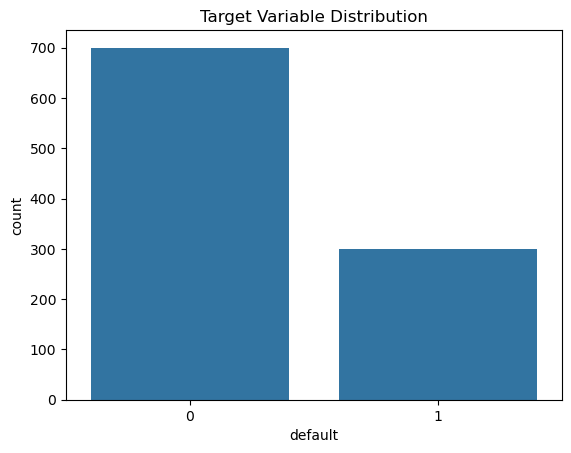

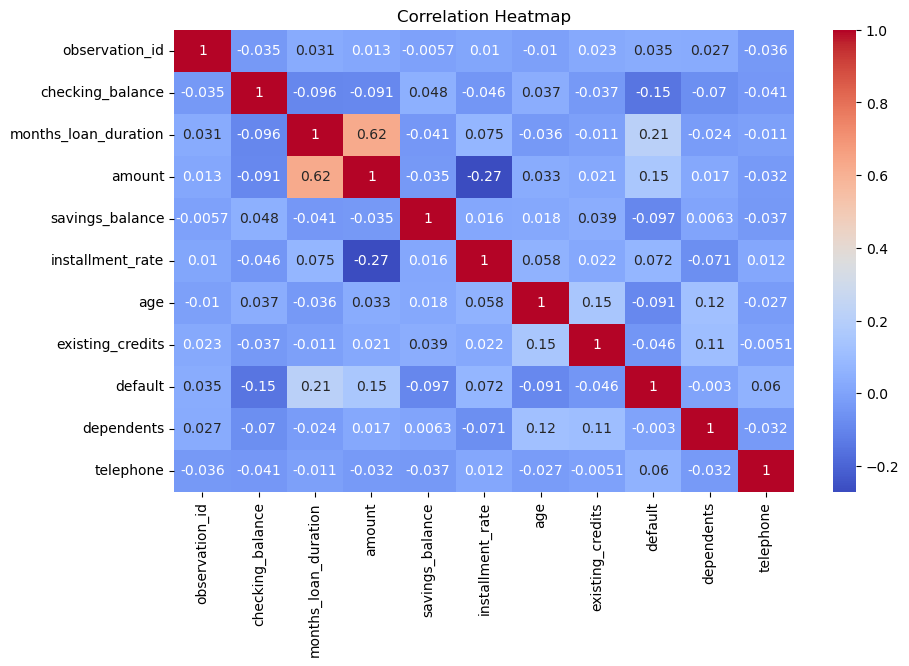

In [36]:
#Visualization
sns.countplot(x='default', data=df)
plt.title("Target Variable Distribution")
plt.show()

# Correlation heatmap (only numeric)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


<p style="font-size:22px;"><b>Encode Categorical Variables</b></p>

In [7]:
# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


<p style="font-size:22px;"><b>Define Features & Target</b></p>

In [ ]:
# Features and Target
X = df.drop('default', axis=1)
y = df['default']


<p style="font-size:22px;"><b>Feature Scaling</b></p>

In [38]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<p style="font-size:22px;"><b>Train-Test Split</b></p>

In [47]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<p style="font-size:22px;"><b>Model Training</b></p>

In [48]:
#  MODEL TRAINING
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

model.fit(X_scaled, y)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
# PREDICTION
y_pred = model.predict(X_scaled)
y_prob = model.predict_proba(X_scaled)[:,1]

<p style="font-size:22px;"><b>Evaluation</b></p>

In [50]:
# EVALUATION
accuracy = accuracy_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
auc = roc_auc_score(y, y_prob)

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy:", accuracy)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC:", auc)

print("\nClassification Report:")
print(classification_report(y, y_pred))


===== MODEL PERFORMANCE =====
Accuracy: 1.0
Recall: 1.0
F1 Score: 1.0
AUC-ROC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00       300

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



<p style="font-size:22px;"><b>Confusion Matrix (GRAPH)</b></p>

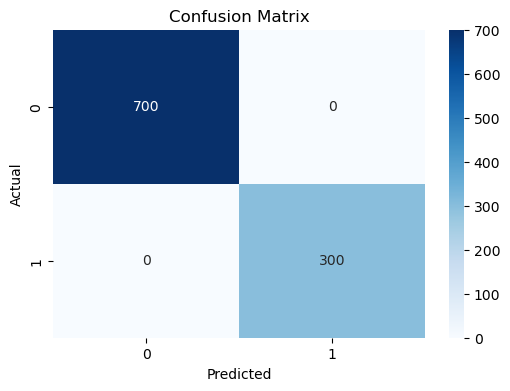

In [45]:
# CONFUSION MATRIX

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


<p style="font-size:22px;"><b>ROC CURVE (GRAPH)</b></p>

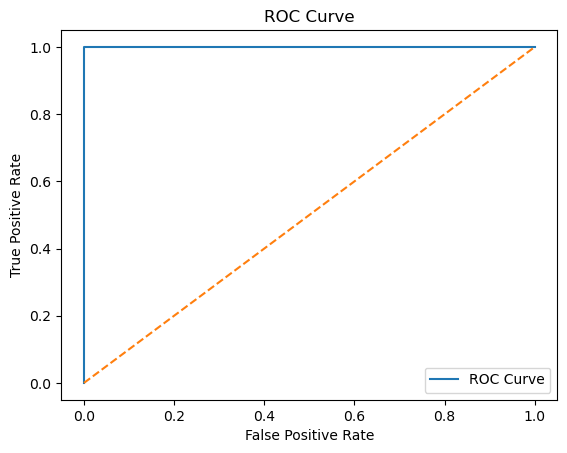

In [51]:
# ROC CURVE

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()